# Desafío Práctico - Algoritmos Evolutivos I

URL: https://github.com/RodriMesa/proyectos_maestria/tree/main/AlgoritmosEvolutivos1

### Integrantes:

- Rodrigo Mesa (a2016)
- Juan Ignacio García (a2008)
- Danilo Reitano (a2020)

En el siguiente documento se implementó una solución para el problema de Sudoku. Las técnicas de algoritmos evolutivos son particularmente interesantes para tratar este estilo de problemas donde el espacio de soluciones es elevado, mientas que el conjunto de reglas es simple. Con estas características se pueden modelar los mecanismos de puntaje, generación de problemas, entrecruzamiento; paralelizando la búsqueda de una solución óptima.

Para esto, se modeló de cero tanto el problema de Sudoku como el algoritmo de resolución.

## 1. Generación del Sudoku

In [14]:
import copy
import numpy as np
import random

import matplotlib.pyplot as plt
from typing import List, Tuple
from tqdm import tqdm

Inicialmente creamos una clase que representa el tablero y contiene funciones de ayuda para facilitar su interpretación para el algoritmo genético. Esto nos permite obtener una fila, columna o caja, validar si ese conjunto es válido, convertirlos a vectores y obtener una representación visual del tablero.

In [15]:
class Sudoku:
    """
    Clase que representa un tablero de Sudoku 9x9.
    Permite manipular, validar y visualizar tableros de Sudoku.
    """
    
    def __init__(self, grid: List[List[int]]):
        """
        Inicializa un tablero de Sudoku.
        
        Args:
            grid: lista de listas 9x9 con enteros del 0 al 9 (0 = vacío).
        
        Raises:
            ValueError: Si el tablero no tiene dimensiones 9x9.
        """
        # Validación: verifica que el tablero tenga exactamente 9 filas
        # y que cada fila tenga exactamente 9 columnas
        if len(grid) != 9 or any(len(row) != 9 for row in grid):
            raise ValueError("El tablero debe ser 9x9.")
        self.grid = grid

    def __repr__(self) -> str:
        """
        Representación visual del Sudoku en formato legible.
        Muestra el tablero con separadores visuales para los bloques 3x3.
        
        Returns:
            String formateado que muestra el tablero con:
            - '.' para celdas vacías (valor 0)
            - Separadores '|' entre bloques horizontales
            - Líneas horizontales '---' entre bloques verticales
        """
        lines = []
        for i, row in enumerate(self.grid):
            # Convertir cada valor en string, usando '.' para los vacíos
            row_str = ""
            for j, val in enumerate(row):
                # Agregar separador '|' cada 3 columnas (excepto al inicio)
                sep = " "
                if j % 3 == 0 and j != 0:
                    sep = " | "
                # Mostrar el número o '.' si está vacío
                row_str += sep + (str(val) if val != 0 else ".")
            lines.append(row_str.strip())

            # Línea horizontal después de cada bloque de 3 filas
            # (excepto después de la última fila)
            if (i + 1) % 3 == 0 and i != 8:
                lines.append("-" * 21)

        return "\n".join(lines)

    def get_row(self, r: int) -> List[int]:
        """
        Obtiene todos los valores de una fila específica.
        
        Args:
            r: índice de la fila (0-8)
        
        Returns:
            Lista con los 9 valores de la fila
        """
        return self.grid[r]

    def get_col(self, c: int) -> List[int]:
        """
        Obtiene todos los valores de una columna específica.
        
        Args:
            c: índice de la columna (0-8)
        
        Returns:
            Lista con los 9 valores de la columna
        """
        # Extrae el valor en la columna c de cada fila
        return [self.grid[i][c] for i in range(9)]

    def get_box(self, box_row: int, box_col: int) -> List[int]:
        """
        Obtiene todos los valores de una subcuadrícula 3x3 (caja).
        
        Args:
            box_row: índice de la fila de cajas (0-2)
            box_col: índice de la columna de cajas (0-2)
        
        Returns:
            Lista con los 9 elementos de la subcuadrícula 3x3
        
        Nota:
            El tablero tiene 3x3 = 9 cajas. Cada caja es una subcuadrícula 3x3.
        """
        # Calcula las coordenadas de inicio de la caja en el tablero
        # Ejemplo: box_row=1, box_col=2 -> start_r=3, start_c=6
        start_r, start_c = box_row * 3, box_col * 3
        # Extrae todos los valores de la caja 3x3
        return [
            self.grid[r][c]
            for r in range(start_r, start_r + 3)
            for c in range(start_c, start_c + 3)
        ]

    def is_valid(self) -> bool:
        """
        Verifica que el Sudoku esté completamente resuelto y sea válido.
        
        Un Sudoku válido debe cumplir:
        1. Cada fila contiene los números 1-9 sin repetir
        2. Cada columna contiene los números 1-9 sin repetir
        3. Cada caja 3x3 contiene los números 1-9 sin repetir
        
        Returns:
            True si el Sudoku está completamente resuelto y es válido,
            False en caso contrario
        """
        # Conjunto esperado: {1, 2, 3, 4, 5, 6, 7, 8, 9}
        nums = set(range(1, 10))
        
        # Verificar cada fila y columna
        for i in range(9):
            # Verifica que la fila i contenga exactamente los números 1-9
            if set(self.get_row(i)) != nums:
                return False
            # Verifica que la columna i contenga exactamente los números 1-9
            if set(self.get_col(i)) != nums:
                return False
        
        # Verificar cada una de las 9 cajas 3x3
        for br in range(3):  # 3 filas de cajas
            for bc in range(3):  # 3 columnas de cajas
                # Verifica que la caja contenga exactamente los números 1-9
                if set(self.get_box(br, bc)) != nums:
                    return False
        
        return True

    def get_vector(self) -> np.ndarray:
        """
        Convierte el tablero 2D en un vector 1D (array plano).
        
        Útil para algoritmos genéticos que trabajan con representaciones
        unidimensionales del problema.
        
        Returns:
            Array numpy de 81 elementos (9x9 = 81)
        """
        # Convierte la lista de listas en array numpy y la aplana
        vector = np.array(self.grid).flatten()
        return vector


La siguiente clase `SudokuGenerator`, nos permite generar un nuevo problema de manera aleatoria para luego ser resuelto por el algoritmo genético. La cantidad de espacios vaciós en el problema es configurable. De esta manera podemos aumentar o disminuír la dificultad del problema.

In [16]:
class SudokuGenerator:
    """
    Clase estática para generar sudokus válidos y resolubles.
    Puede generar sudokus completos o con huecos (puzzles).
    """

    @staticmethod
    def generate_full() -> Sudoku:
        """
        Genera una solución completa de Sudoku usando backtracking.
        
        El algoritmo:
        1. Comienza con un tablero vacío (todos ceros)
        2. Llena las celdas una por una probando valores válidos
        3. Si llega a un punto sin solución, retrocede (backtracking)
        4. Usa números aleatorios para generar diferentes soluciones
        
        Returns:
            Un objeto Sudoku completamente resuelto y válido
        """
        def is_valid(value: int, row: int, col: int, grid: List[List[int]]) -> bool:
            """
            Verifica si un valor puede colocarse en una posición específica.
            
            Un valor es válido si:
            - No está en la misma fila
            - No está en la misma columna
            - No está en la misma caja 3x3
            
            Args:
                value: número a verificar (1-9)
                row: fila donde se quiere colocar
                col: columna donde se quiere colocar
                grid: tablero actual
            
            Returns:
                True si el valor es válido en esa posición, False en caso contrario
            """
            # Calcula la esquina superior izquierda de la caja 3x3 que contiene (row, col)
            # Ejemplo: row=5, col=7 -> r0=3, c0=6 (caja en fila 1, columna 2)
            r0 = row - row % 3
            c0 = col - col % 3
            
            # Verifica que el valor no esté en la fila
            row_ok = value not in grid[row]

            # Validación con corto circuito
            if not row_ok:
                return False
            
            # Verifica que el valor no esté en la columna
            col_ok = value not in [grid[i][col] for i in range(9)]

            # Validación con corto circuito
            if not col_ok:
                return False
            
            # Verifica que el valor no esté en la caja 3x3
            box_ok = value not in [
                grid[r0 + i][c0 + j]
                for i in range(3)
                for j in range(3)
            ]
            
            # El valor es válido solo si pasa las tres verificaciones
            return box_ok

        def solve(grid: List[List[int]]) -> bool:
            """
            Resuelve el Sudoku usando backtracking recursivo.
            
            Algoritmo:
            1. Busca la primera celda vacía (valor 0)
            2. Prueba números del 1 al 9 en orden aleatorio
            3. Si encuentra un número válido, lo coloca y recursivamente
               intenta resolver el resto del tablero
            4. Si la recursión falla, deshace el cambio (backtracking)
               y prueba el siguiente número
            5. Si no hay celdas vacías, el tablero está resuelto
            
            Args:
                grid: tablero a resolver (se modifica in-place)
            
            Returns:
                True si se encontró una solución, False si no hay solución
            """
            # Busca la primera celda vacía
            for row in range(9):
                for col in range(9):
                    if grid[row][col] == 0:  # Celda vacía encontrada
                        # Prueba números del 1 al 9 en orden aleatorio
                        # (esto genera diferentes soluciones cada vez)
                        for num in random.sample(range(1, 10), 9):
                            if is_valid(num, row, col, grid):
                                # Coloca el número si es válido
                                grid[row][col] = num
                                # Intenta resolver el resto recursivamente
                                if solve(grid):
                                    return True  # Solución encontrada
                                # Si llegamos aquí, este número no llevó a solución
                                # Deshace el cambio (backtracking)
                                grid[row][col] = 0
                        # Si ningún número funcionó, no hay solución desde aquí
                        return False
            # No hay celdas vacías: el tablero está completamente resuelto
            return True

        # Inicializa un tablero vacío (todas las celdas son 0)
        grid = [[0] * 9 for _ in range(9)]
        # Resuelve el tablero usando backtracking
        solve(grid)
        # Retorna un objeto Sudoku con la solución completa
        return Sudoku(grid)

    @staticmethod
    def generate_puzzle(holes: int = 40) -> Sudoku:
        """
        Genera un Sudoku con una cantidad específica de huecos (celdas vacías).
        
        Proceso:
        1. Genera un Sudoku completo válido
        2. Selecciona posiciones aleatorias
        3. Vacía esas posiciones (las convierte en 0)
        
        Args:
            holes: número de celdas a vaciar (default: 40)
                  Un valor típico es 40-50 para un puzzle de dificultad media
        
        Returns:
            Un objeto Sudoku con huecos (puzzle para resolver)
        """
        # Genera un Sudoku completamente resuelto
        sudoku = SudokuGenerator.generate_full()
        # Hace una copia profunda para no modificar el original
        grid = copy.deepcopy(sudoku.grid)
        
        # Genera todas las posibles posiciones (r, c) del tablero
        positions = [(r, c) for r in range(9) for c in range(9)]
        # Mezcla aleatoriamente las posiciones
        random.shuffle(positions)
        
        # Vacía las primeras 'holes' posiciones de la lista mezclada
        for i in range(holes):
            r, c = positions[i]
            grid[r][c] = 0  # Marca la celda como vacía
        
        return Sudoku(grid)

In [17]:
# Crear un Sudoku con huecos
puzzle = SudokuGenerator.generate_puzzle(holes=40)
print("\nSudoku con huecos:")
print(puzzle)


Sudoku con huecos:
3 7 8 | . . . | . . .
4 5 1 | . 2 . | . . 7
2 . . | 5 . . | . 4 1
---------------------
5 . 4 | . 6 . | 8 2 3
8 . 7 | . . . | 4 1 .
. 1 . | . . 8 | . 5 .
---------------------
9 . . | 2 1 3 | . . .
7 . 3 | 6 . 5 | 1 . 8
1 4 5 | . 7 . | 6 . 2


A continuación generamos la máscara inicial. La misma va a ser ulizada durante la resolución para representar las celdas fijas del problema.

In [18]:
initial_mask = puzzle.get_vector()

La función `generate_childs` será la encargada de generar la población inicial para el algoritmo. Se generan n individuos de la población y luego se utiliza la máscara para fijar las celdas iniciales.

In [19]:
def generate_childs(initial_mask: np.ndarray, n: int) -> np.ndarray:
    """
    Genera una población inicial de n individuos para el algoritmo genético.
    
    Cada individuo es una posible solución al Sudoku que respeta las celdas fijas
    pero tiene valores aleatorios en las celdas vacías.
    
    Args:
        initial_mask: Array numpy 1D de 81 elementos que representa el Sudoku inicial
                     con celdas fijas (valores != 0) y celdas vacías (valores == 0)
        n: Número de individuos a generar en la población inicial
    
    Returns:
        Array numpy 2D de forma (n, 81) donde cada fila es un individuo de la población.
        Cada individuo es una posible solución parcial al Sudoku.
    """
    # Genera n individuos, cada uno con valores aleatorios en las celdas vacías
    children = np.random.randint(1, 10, size=(n, initial_mask.size))
    
    # Preserva las celdas fijas para todos los individuos de una vez
    # Usa broadcasting: cada fila (individuo) recibe los valores fijos
    fixed_mask = initial_mask != 0
    children[:, fixed_mask] = initial_mask[fixed_mask]
    
    return children

La función `fitness` nos permite evaluar la condición del individuo y su calidad como solución. En nuestro caso usamos una metodología de puntuación donde se suman los valores únicos en cada fila/columna/caja. De esta manera, mientras más alto el valor, más cercano a la solución real, donde el mínimo es 27 (cada conjunto tiene solo un valor único) y el máximo es 243 (no hay números repetidos en ningún conjunto).

In [20]:
def fitness(candidate: np.ndarray) -> int:
    """
    Evalúa la calidad de un candidato como solución al Sudoku.
    
    La función de fitness mide qué tan cerca está el candidato de ser una solución válida.
    Un Sudoku válido debe tener:
    - Cada fila con los números 1-9 sin repetir
    - Cada columna con los números 1-9 sin repetir
    - Cada caja 3x3 con los números 1-9 sin repetir
    
    La función cuenta cuántos valores únicos hay en cada fila, columna y caja.
    Un valor más alto indica menos repeticiones y por tanto una mejor solución.
    
    Args:
        candidate: Array numpy 1D de 81 elementos que representa un candidato a solución.
                  Se espera que contenga valores del 1 al 9.
    
    Returns:
        Puntuación de fitness (int) en el rango [27, 243]:
        - Mínimo: 27 (si cada fila/columna/caja tiene solo 1 valor único)
        - Máximo: 243 (si no hay repeticiones: 9 filas × 9 únicos + 9 columnas × 9 únicos + 9 cajas × 9 únicos)
        - Un Sudoku válido y completo debería tener 243 puntos
    """
    # Convierte el vector 1D en una matriz 9x9 para trabajar con filas, columnas y cajas
    grid = candidate.reshape((9, 9))

    score = 0
    # Evalúa cada una de las 9 filas, 9 columnas y 9 cajas
    for i in range(9):
        # Obtiene la fila i y cuenta valores únicos
        score += len(np.unique(grid[i, :]))
        # Obtiene la columna i y cuenta valores únicos
        score += len(np.unique(grid[:, i]))
        # Obtiene la caja i (calcula índices de la caja 3x3 correspondiente)
        # i//3 da la fila de cajas (0, 1, 2), i%3 da la columna de cajas (0, 1, 2)
        box = grid[(i//3)*3:(i//3)*3+3, (i%3)*3:(i%3)*3+3]
        score += len(np.unique(box))

    # Máximo posible = 9 filas × 9 únicos + 9 columnas × 9 únicos + 9 cajas × 9 únicos = 243
    # Esto ocurre cuando no hay repeticiones en ninguna fila, columna o caja
    return score

En la `cruza` realizamos un cruce uniforme. Una máscara binaria aleatoria decide que celda se hereda de cada padre. En este caso se generan dos hijos complementarios.

En nuestro caso de configuró la probabilidad threshold en 0.5, de esta manera ambos padres tienen el mismo peso en la generación de hijos.

No es necesario tener en cuenta la máscara inicial en la cruza ya que ambos padres tienen los valores correctos en dichas celdas fijas. No importa que padre logre imponer su gen, siempre el valor será el correcto.

Este mecanismo de cruza es relativamente simple, en nuesto caso encontramos buenos resultados con el mismo.

In [21]:
def cruza(individuals: Tuple[np.ndarray, np.ndarray]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Realiza el cruce (crossover) entre dos padres para generar dos hijos.
    
    Utiliza un cruce uniforme (uniform crossover):
    - Se genera una máscara binaria aleatoria
    - Cada posición del hijo se toma del padre1 o padre2 según la máscara
    - Se generan dos hijos complementarios
    
    Args:
        individuals: Tupla con dos arrays numpy 1D de 81 elementos cada uno.
                    Representan los dos padres que se van a cruzar.
    
    Returns:
        Tupla con dos arrays numpy 1D de 81 elementos:
        - child1: Hijo que toma valores de parent1 donde mask==1, de parent2 donde mask==0
        - child2: Hijo complementario (toma valores de parent2 donde mask==1, de parent1 donde mask==0)
    """
    parent1, parent2 = individuals
    # Genera máscara booleana para cada posición
    # Esta máscara determina de qué padre se toma cada gen
    mask = np.random.random(size=parent1.size) < 0.5  # True/False en lugar de 0/1
    
    # Crea los dos hijos usando la máscara
    # child1: toma de parent1 donde mask==True, de parent2 donde mask==False
    child1 = np.where(mask, parent1, parent2)
    # child2: toma de parent2 donde mask==True, de parent1 donde mask==False (complementario)
    child2 = np.where(mask, parent2, parent1)
    
    return child1, child2

La función `mutate` introduce variabilidad genética en los entrecruzamientos. En nuestro caso de determinó una probabilidad de mutación del 0.1. Es decir, solo uno de cada 10 genes son mutados.

Es importante destacar que solo están disponibles para mutación las celdas que no estén fijas en la máscara inicial.

La celda que resulte mutada tendrá un número aleatorio entre 1 y 9 incluído.

In [22]:
def mutate(child: np.ndarray, initial_mask: np.ndarray, mutation_prob: float = 0.1) -> np.ndarray:
    """
    Aplica mutación a un individuo con una probabilidad dada.
    
    La mutación introduce variabilidad genética en la población:
    - Cada gen (posición) tiene una probabilidad 'mutation_prob' de ser mutado
    - Si se muta, se reemplaza por un valor aleatorio del 1 al 9
    - Las celdas fijas (initial_mask != 0) siempre se preservan
    
    Args:
        child: Array numpy 1D de 81 elementos que representa el individuo a mutar
        initial_mask: Array numpy 1D de 81 elementos con las celdas fijas del Sudoku original.
                     Los valores != 0 son celdas que no deben cambiar.
        mutation_prob: Probabilidad de mutación para cada gen (default: 0.1 = 10%)
    
    Returns:
        Array numpy 1D de 81 elementos con el individuo mutado.
        Las celdas fijas mantienen su valor original, las demás pueden haber mutado.
    """
    mutated_child = child.copy()
    
    # Genera números aleatorios entre 0 y 1 para decidir qué genes mutar
    random_choices = np.random.random(size=child.size)
    
    # Solo muta posiciones que no son fijas (initial_mask == 0)
    mutable_positions = (random_choices < mutation_prob) & (initial_mask == 0)
    
    # Solo genera valores aleatorios para las posiciones que se van a mutar
    if np.any(mutable_positions):
        mutated_child[mutable_positions] = np.random.randint(1, 10, size=np.sum(mutable_positions))
    
    return mutated_child

In [23]:
def evaluate_scores(individuals: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Evalúa el fitness de todos los individuos de la población.
    
    Calcula tanto los scores brutos como los normalizados (probabilidades).
    Los scores normalizados se usan para la selección probabilística,
    donde individuos con mejor fitness tienen mayor probabilidad de ser seleccionados.
    
    Args:
        individuals: Array numpy 2D de forma (n, 81) donde cada fila es un individuo.
                    Representa la población completa a evaluar.
    
    Returns:
        Tupla con dos arrays numpy 1D:
        - normalized_scores: Scores normalizados (suman 1.0) usados como probabilidades
                           para selección. Individuos mejores tienen valores más altos.
        - individuals_scores: Scores brutos de fitness para cada individuo.
                             Valores más altos indican mejor solución.
    """
    # Calcula el fitness de cada individuo en la población
    individuals_scores = np.array([fitness(indiv) for indiv in individuals])
    # Normaliza los scores dividiendo por la suma total
    # Esto convierte los scores en probabilidades (suman 1.0)
    # Útil para selección proporcional al fitness
    normalized_scores = individuals_scores / np.sum(individuals_scores)
    return normalized_scores, individuals_scores

La función `genetic_algorithm` ejecuta el algoritmo para encontrar una solución.

El primer paso es el elitismo, donde en nuestro caso estamos preservando los n mejores individuos (basados en la función de fitness) de cada iteración para que pasen directamente a la siguiente generación. Este número es par para poder preservar el tamaño de la población.

Se calcula la cantidad de cruces a generar, el cual será la mitad del número de individuos restantes en la población.

Para elegir los padres de cada cruza, se los ordena según su fitness y se hace un random choice con ponderación según dicha puntuación. Dicha selección se realiza con sustitución.

Finalmente se aplica el cruce y mutación sobre los hijos generados.

In [24]:
def genetic_algorithm(parents: np.ndarray, initial_mask: np.ndarray, elite_num: int = 2, mutation_prob: float = 0.1) -> np.ndarray:
    """
    Ejecuta una iteración del algoritmo genético.
    
    El algoritmo genético combina varias técnicas:
    1. Elitismo: preserva los mejores individuos sin modificación
    2. Selección: elige padres basándose en su fitness (mejor fitness = mayor probabilidad)
    3. Cruce: combina dos padres para generar dos hijos
    4. Mutación: introduce variabilidad en los hijos generados
    
    Args:
        parents: Array numpy 2D de forma (n, 81) con la población actual.
                Cada fila es un individuo (candidato a solución).
        initial_mask: Array numpy 1D de 81 elementos con las celdas fijas del Sudoku.
                     Se usa para preservar las celdas originales durante la mutación.
        elite_num: Número de mejores individuos a preservar sin modificar (default: 2).
                  Estos pasan directamente a la siguiente generación.
    
    Returns:
        Array numpy 2D de forma (n, 81) con la nueva generación de individuos.
        La población mantiene el mismo tamaño que la generación anterior.
    """
    # Obtiene el número total de individuos en la población
    total_individuos = parents.shape[0]
    total_elite = elite_num

    # Calcula cuántos cruces se necesitan para llenar la población
    # Cada cruce produce 2 hijos, y se reservan 'elite_num' espacios para los élites
    canditad_cruces = int((total_individuos - total_elite) / 2)

    # Evalúa el fitness de todos los padres
    # parent_scores son las probabilidades normalizadas para selección
    parent_scores, _ = evaluate_scores(parents)
    
    # Selección por elitismo: encuentra los índices de los 'elite_num' mejores individuos
    # argpartition es más eficiente que ordenar todo el array
    idx = np.argpartition(parent_scores, -elite_num)[-elite_num:]  # Unsorted top-n indices
    # Ordena los índices de mayor a menor fitness
    idx = idx[np.argsort(parent_scores[idx])[::-1]]  # Sort them descending by value

    # Pre-asigna el array final
    final_childs = np.empty((total_individuos, 81), dtype=parents.dtype)
    
    # Copia los mejores individuos (élites) para preservarlos
    final_childs[-elite_num:] = parents[idx]  # Coloca élites al final

    # Pre-asigna espacio para los hijos generados por cruce
    crossover_children = np.empty((canditad_cruces * 2, 81), dtype=parents.dtype)
    
    # Genera nuevos individuos mediante cruce
    for i in range(canditad_cruces):
        # Selección proporcional al fitness: mejores individuos tienen mayor probabilidad
        # de ser seleccionados como padres
        selected_indices = np.random.choice(len(parents), size=2, p=parent_scores)
        selected_childs = (parents[selected_indices[0]], parents[selected_indices[1]])
        
        # Cruza los dos padres seleccionados para generar dos hijos
        child1, child2 = cruza(selected_childs)
        crossover_children[i*2] = child1
        crossover_children[i*2 + 1] = child2
    
    # Aplica mutación a todos los hijos de una vez
    for i in range(len(crossover_children)):
        crossover_children[i] = mutate(crossover_children[i], initial_mask, mutation_prob)
    
    # Coloca los hijos mutados al inicio del array final
    final_childs[:-elite_num] = crossover_children

    return final_childs

In [25]:
def plot_algorithm(max_values, median) -> None:
    # Visualiza el progreso del algoritmo genético a lo largo de las generaciones
    # Muestra cómo evoluciona el fitness máximo y promedio de la población
    plt.figure(figsize=(10, 5))

    # Grafica el fitness máximo de cada generación
    # Indica la calidad del mejor individuo encontrado hasta el momento
    plt.plot(range(len(max_values)), max_values, label="Max Fitness", linewidth=2)

    # Grafica el fitness promedio (media) de cada generación
    # Indica la calidad general de la población
    plt.plot(range(len(max_values)), median, label="Mean Fitness", linestyle="--", linewidth=2)

    # Configuración de la gráfica
    plt.title("Genetic Algorithm Progress", fontsize=14)
    plt.xlabel("Iteration", fontsize=12)
    plt.ylabel("Fitness", fontsize=12)
    # Limita el rango del eje Y para mejor visualización
    # El fitness máximo posible es 243 (Sudoku completamente válido)
    plt.ylim([150, 250])
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.show()


A continuación se ejecuta el algoritmo con 1000 generaciones de 1000 individuos, donde los mejores 200 pasan a la siguiente iteración por elitismo.

Durante la ejecución vamos guardando el fitness del mejor individuo de dicha iteración y el fitness promedio de toda la población en dicha iteración. Esto nos permite graficar la evolución de la población.

Running Genetic Algorithm:  49%|████▊     | 486/1000 [01:51<01:58,  4.36it/s]


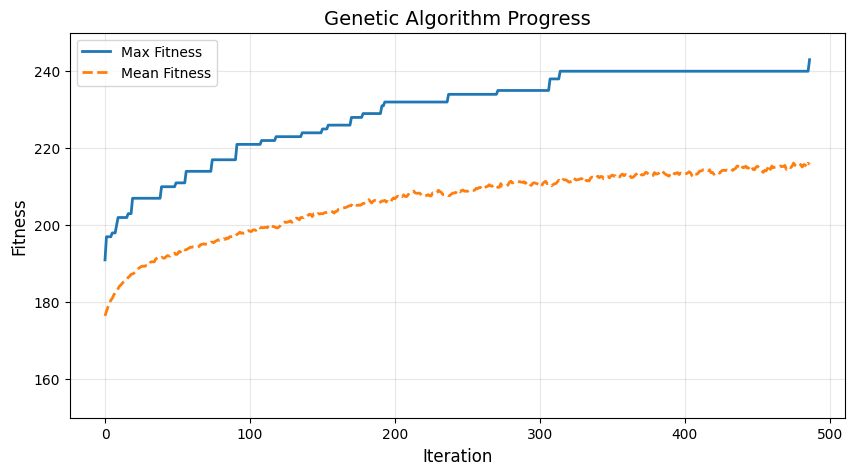

In [26]:
# Parámetros del algoritmo genético
number_iterations = 1000  # Número de generaciones a ejecutar
number_childs = 1000      # Tamaño de la población (número de individuos)
number_elite = 200        # Número de mejores individuos a preservar en cada generación

# Genera la población inicial con valores aleatorios en las celdas vacías
childs = generate_childs(initial_mask, number_childs)

# Inicializa listas para almacenar el progreso del algoritmo
iterations = list(range(number_iterations))
max_values: List[float] = []  # Almacena el mejor fitness de cada generación
median: List[float] = []       # Almacena el fitness promedio de cada generación

# Ejecuta el algoritmo genético por 'number_iterations' generaciones
for i in tqdm(iterations, desc="Running Genetic Algorithm"):
    # Ejecuta una iteración del algoritmo genético
    # Genera una nueva población a partir de la actual
    childs = genetic_algorithm(childs.copy(), initial_mask, number_elite)
    # Evalúa el fitness de la nueva generación
    _, childs_scores = evaluate_scores(childs)
    
    # Registra estadísticas de la generación actual
    max_values.append(childs_scores.max())      # Mejor individuo de esta generación
    median.append(childs_scores.mean())         # Fitness promedio de esta generación

    if max_values[-1] == 243:
        break

plot_algorithm(max_values, median)
    


En el gráfico se puede observar que se encontró la solución única al problema (fitness score 483) alrededor de la iteración 350 de la ejecución del algoritmo.

In [ ]:
# Muestra el mejor fitness alcanzado después de todas las iteraciones
# Un valor de 243 indica un Sudoku completamente válido (sin repeticiones)
childs_scores.max()

np.int64(243)

In [ ]:
# Selecciona el mejor individuo de la población final
# argmax encuentra el índice del individuo con mayor fitness
solution: np.ndarray = childs[np.argmax(childs_scores)]

In [ ]:
# Convierte el vector solución en un objeto Sudoku para validación y visualización
# reshape convierte el array 1D de 81 elementos en una matriz 9x9
solution = Sudoku(solution.reshape((9, 9)))

In [ ]:
# Verifica si la solución encontrada es un Sudoku válido y completamente resuelto
# Retorna True si cada fila, columna y caja 3x3 contiene exactamente los números 1-9
solution.is_valid()

True

Utilizando los helpers de la clase Sudoku podemos representar visualmente la solución final.

In [ ]:
# Muestra la solución encontrada en formato visual
# Los números representan la solución propuesta por el algoritmo genético
solution

2 6 8 | 5 3 4 | 9 1 7
5 3 7 | 8 9 1 | 2 4 6
1 4 9 | 6 2 7 | 8 3 5
---------------------
9 1 2 | 4 6 8 | 7 5 3
6 7 4 | 9 5 3 | 1 2 8
8 5 3 | 7 1 2 | 4 6 9
---------------------
4 8 6 | 2 7 5 | 3 9 1
3 2 5 | 1 8 9 | 6 7 4
7 9 1 | 3 4 6 | 5 8 2

### Prueba adicional: cambio de logica generacion

Para evaluar variantes de la solución, se propuso desarrollar otra función generadora de hijos iniciales. La diferencia con la nueva es que esta busca aportar mayor lógica a la solución: los hijos que se generan no son valores aleatorios unicamente, sino que se busca completar el tablero con un conjunto completo de numeros que corresponde: 9 unos, 9 dos, etc.; aunque no sean una solución. De esta forma buscamos tener un conjunto mas acotado de busqueda (mas cercano a la solución).


In [28]:
def generate_childs_2(initial_mask: np.ndarray, n: int) -> np.ndarray:
    """
    Genera una población inicial de n individuos para el algoritmo genético.
    
    Cada individuo es una posible solución al Sudoku que respeta las celdas fijas
    pero tiene valores aleatorios en las celdas vacías. Ahora utilizamos
    ``np.random.choice`` sobre un pool balanceado para asegurar que cada dígito (1-9)
    aparezca exactamente nueve veces en el tablero completo.
    
    Args:
        initial_mask: Array numpy 1D de 81 elementos que representa el Sudoku inicial
                     con celdas fijas (valores != 0) y celdas vacías (valores == 0)
        n: Número de individuos a generar en la población inicial
    
    Returns:
        Array numpy 2D de forma (n, 81) donde cada fila es un individuo de la población.
        Cada individuo es una posible solución parcial al Sudoku.
    """
    fixed_mask = initial_mask != 0
    empty_mask = ~fixed_mask
    empty_slots = empty_mask.sum()

    # Contamos cuántas veces aparece cada dígito fijo para saber cuántos faltan
    counts = np.bincount(initial_mask[fixed_mask], minlength=10)[1:10]
    needed_counts = 9 - counts

    # Construimos el pool balanceado (ej: nueve 1s, nueve 2s, etc. considerando la máscara)
    balanced_digits = np.repeat(np.arange(1, 10), needed_counts)

    # Si no hay celdas vacías simplemente repetimos la máscara
    if empty_slots == 0:
        return np.tile(initial_mask, (n, 1))

    children = np.empty((n, initial_mask.size), dtype=int)
    children[:, fixed_mask] = initial_mask[fixed_mask]

    for idx in range(n):
        # np.random.choice sin reemplazo garantiza que respetemos la cantidad de cada dígito
        shuffled = np.random.choice(balanced_digits, size=balanced_digits.size, replace=False)
        child = children[idx]
        child[empty_mask] = shuffled

    return children

Al evaluar los resultados, obtenemos:

Running Genetic Algorithm:   0%|          | 0/1000 [00:00<?, ?it/s]

Running Genetic Algorithm:  28%|██▊       | 283/1000 [01:05<02:45,  4.33it/s]


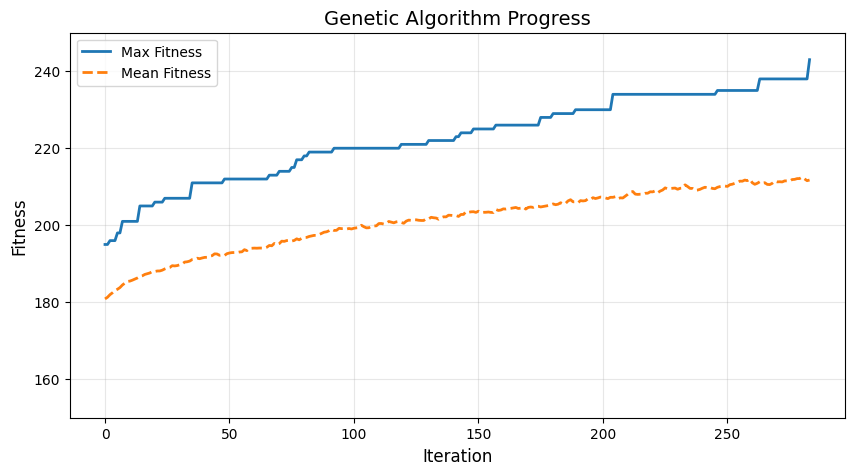

In [ ]:
# Parámetros del algoritmo genético
number_iterations = 1000  # Número de generaciones a ejecutar
number_childs = 1000      # Tamaño de la población (número de individuos)
number_elite = 200        # Número de mejores individuos a preservar en cada generación
mutation_prob = 0.1

# Genera la población inicial con valores aleatorios en las celdas vacías
childs = generate_childs_2(initial_mask, number_childs)

# Inicializa listas para almacenar el progreso del algoritmo
iterations = list(range(number_iterations))
max_values: List[float] = []  # Almacena el mejor fitness de cada generación
median: List[float] = []       # Almacena el fitness promedio de cada generación

# Ejecuta el algoritmo genético por 'number_iterations' generaciones
for i in tqdm(iterations, desc="Running Genetic Algorithm"):
    # Ejecuta una iteración del algoritmo genético
    # Genera una nueva población a partir de la actual
    childs = genetic_algorithm(childs.copy(), initial_mask, number_elite, mutation_prob)
    # Evalúa el fitness de la nueva generación
    _, childs_scores = evaluate_scores(childs)
    
    # Registra estadísticas de la generación actual
    max_values.append(childs_scores.max())      # Mejor individuo de esta generación
    median.append(childs_scores.mean())         # Fitness promedio de esta generación

    if max_values[-1] == 243:
        break
plot_algorithm(max_values, median)

## Resultados:

Podemos observar que para este caso, el algoritmo original converge a una solución en la iteración 486, mientras que con la nueva función, en la 283. Esto es un único caso, y no representa el comportamiento general del algoritmo, pero nos muestra un patrón interesante: el desempeño de estos algoritmos se encuentra estrechamente ligado a los mecanismos que podamos diseñar para generar hijos, realizar entrecruzamiento, etc. 